# IT5006 - EDA starter
## SmartCommerce Data Exploration

**Duration:** ~60 minutes  
**Prerequisites:** Lab 1.0 (Python/PyTorch Refresher)  
**Environment:** Google Colab (recommended) or local Jupyter

---

### 🎯 Learning Objectives

This mini lab is for you to:

1. Load and understand the **Olist e-commerce dataset** schema
2. **Merge multiple tables** using relational keys (order_id, customer_id, product_id)
3. Compute foundational **business KPIs** (Revenue, AOV, Repeat Rate, On-Time Delivery)
4. Create basic **visualizations** to understand data distributions
5. Document the data assets available for downstream analytics

---

### 📊 About the Dataset

**Olist** is a Brazilian e-commerce platform. The dataset contains ~100K orders from 2016-2018 across 9 interconnected tables:

| Table | Description | Key Columns |
|-------|-------------|-------------|
| `orders` | Order metadata & timestamps | order_id, customer_id, status, timestamps |
| `order_items` | Line items per order | order_id, product_id, price, freight |
| `customers` | Customer location | customer_id, city, state |
| `products` | Product catalog | product_id, category, dimensions |
| `sellers` | Seller location | seller_id, city, state |
| `payments` | Payment details | order_id, payment_type, value |
| `reviews` | Customer feedback | order_id, score, comment |
| `geolocation` | Zip code coordinates | zip_code, lat, lng |
| `category_translation` | Portuguese → English | category names |

> 💡 **SmartCommerce** is our fictional brand name for this e-commerce case study throughout the course.


---

## 1. Environment Setup & Data Loading


In [4]:
# Running locally from the repo — no Google Drive mount needed.
# (In Colab instead: `from google.colab import drive; drive.mount('/content/drive')`)

In [ ]:
# Install dependencies (uncomment if running in Colab)
# !pip install -q pandas numpy matplotlib seaborn plotly

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


pandas: 2.3.3
numpy: 2.0.2


In [6]:
# === DATA PATH CONFIGURATION ===
DATA_DIR = '../Olist_data'   # CSVs at the repo root; this notebook runs from notebooks/

# Verify data directory exists
if os.path.exists(DATA_DIR):
    print(f"✅ Data directory found: {DATA_DIR}")
    print(f"   Files: {sorted(os.listdir(DATA_DIR))}")
else:
    print(f"❌ Data directory not found: {DATA_DIR}")
    print("   Update DATA_DIR to point to your Olist CSV folder")

✅ Data directory found: ../Olist_data
   Files: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [7]:
# Load all Olist tables
def load_olist_data(data_dir):
    """Load all Olist CSV files into a dictionary of DataFrames."""

    tables = {
        'orders': 'olist_orders_dataset.csv',
        'order_items': 'olist_order_items_dataset.csv',
        'customers': 'olist_customers_dataset.csv',
        'products': 'olist_products_dataset.csv',
        'sellers': 'olist_sellers_dataset.csv',
        'payments': 'olist_order_payments_dataset.csv',
        'reviews': 'olist_order_reviews_dataset.csv',
        'geolocation': 'olist_geolocation_dataset.csv',
        'category_translation': 'product_category_name_translation.csv'
    }

    # Date columns to parse
    date_cols = {
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date',
                   'order_estimated_delivery_date'],
        'order_items': ['shipping_limit_date'],
        'reviews': ['review_creation_date', 'review_answer_timestamp']
    }

    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows × {data[name].shape[1]} cols")

    return data

# Load data
olist = load_olist_data(DATA_DIR)

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols
Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols
Loaded reviews: 99,224 rows × 7 cols
Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


---

## 2. Schema Exploration

Let's understand each table's structure and relationships.


In [8]:
# Quick schema overview
def schema_summary(data_dict):
    """Generate a summary of all tables."""
    summary = []
    for name, df in data_dict.items():
        summary.append({
            'Table': name,
            'Rows': f"{df.shape[0]:,}",
            'Columns': df.shape[1],
            'Memory (MB)': f"{df.memory_usage(deep=True).sum() / 1e6:.2f}",
            'Columns List': ', '.join(df.columns[:5]) + ('...' if len(df.columns) > 5 else '')
        })
    return pd.DataFrame(summary)

schema_summary(olist)

,Table,Rows,Columns,Memory (MB),Columns List
0,orders,"99,441",8,28.24,"order_id, customer_id, order_status, order_pur..."
1,order_items,"112,650",7,33.68,"order_id, order_item_id, product_id, seller_id..."
2,customers,"99,441",5,31.06,"customer_id, customer_unique_id, customer_zip_..."
3,products,"32,951",9,7.12,"product_id, product_category_name, product_nam..."
4,sellers,"3,095",4,0.69,"seller_id, seller_zip_code_prefix, seller_city..."
5,payments,"103,886",5,18.68,"order_id, payment_sequential, payment_type, pa..."
6,reviews,"99,224",7,31.33,"review_id, order_id, review_score, review_comm..."
7,geolocation,"1,000,163",5,152.26,"geolocation_zip_code_prefix, geolocation_lat, ..."
8,category_translation,71,2,0.01,"product_category_name, product_category_name_e..."


### 2.1 Orders Table (Core Transaction Log)


In [9]:
# Orders - the central fact table
orders = olist['orders']
print("ORDERS TABLE")
print("=" * 50)
print(f"Shape: {orders.shape}")
print(f"\nColumn types:\n{orders.dtypes}")
print(f"\nOrder status distribution:\n{orders['order_status'].value_counts()}")
orders.head(3)

ORDERS TABLE
Shape: (99441, 8)

Column types:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


### 2.2 Order Items Table (Line-Level Details)


In [10]:
# Order Items - contains price and freight
order_items = olist['order_items']
print("ORDER ITEMS TABLE")
print("=" * 50)
print(f"Shape: {order_items.shape}")
print(f"\nPrice statistics:")
print(order_items[['price', 'freight_value']].describe())
order_items.head(3)

ORDER ITEMS TABLE
Shape: (112650, 7)

Price statistics:
          price  freight_value
count 112650.00      112650.00
mean     120.65          19.99
std      183.63          15.81
min        0.85           0.00
25%       39.90          13.08
50%       74.99          16.26
75%      134.90          21.15
max     6735.00         409.68


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87


Is it possible that a product_id is associated with multiple seller_id?



In [11]:
product_seller_count = (
    order_items
    .groupby("product_id")["seller_id"]
    .nunique()
    .reset_index(name="seller_count")
    .sort_values("seller_count", ascending=False)
)

product_seller_count.head()

,product_id,seller_count
27128,d285360f29ac7fd97640bf0baef03de0,8
13626,69455f41626a745aea9ee9164cb9eafd,8
8677,4298b7e67dc399c200662b569563a2b2,7
7131,36f60d45225e60c7da4558b070ce4b60,7
13101,656e0eca68dcecf6a31b8ececfabe3e8,7


Yes. how to interpret it? how are products identified?

does payment match price+freight from order items?

In [12]:
item_totals = (
    order_items
    .assign(item_total=lambda x: x["price"] + x["freight_value"])
    .groupby("order_id", as_index=False)
    .agg(
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        expected_payment=("item_total", "sum")
    )
)
payments = olist['payments']
payment_totals = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        actual_payment=("payment_value", "sum")
    )
)
payment_check = item_totals.merge(
    payment_totals,
    on="order_id",
    how="outer"
)
payment_check["difference"] = (
    payment_check["actual_payment"]
    - payment_check["expected_payment"]
)

payment_check["matches"] = np.isclose(
    payment_check["actual_payment"],
    payment_check["expected_payment"],
    atol=0.01
)

mismatches = payment_check[
    ~payment_check["matches"]
].sort_values("difference", key=abs, ascending=False)

mismatches.head()

,order_id,total_price,total_freight,expected_payment,actual_payment,difference,matches
80176,ce6d150fb29ada17d2082f4847107665,1299.00,104.66,1403.66,1586.47,182.81,False
42865,6e5fe7366a2e1bfbf3257dba0af1267f,179.19,108.72,287.91,406.92,119.01,False
43791,70b742795bc441e94a44a084b6d9ce7a,269.99,196.94,466.93,578.82,111.89,False
59228,996c7e73600ad3723e8627ab7bef81e4,559.90,28.00,587.90,664.43,76.53,False
43794,70b7e94ea46d3e8b5bc12a50186edaf0,167.88,45.27,213.15,274.84,61.69,False


there are orders with mismatching actual and expected payment, is it because of tips for excess? and what could cause the insufficience.

In [13]:
payment_check.isna().sum()

order_id              0
total_price         775
total_freight       775
expected_payment    775
actual_payment        1
difference          776
matches               0
dtype: int64

In [14]:
na_payment_order = payment_check[
    payment_check["actual_payment"].isna()
]
order_id = na_payment_order.iloc[0]["order_id"]

In [15]:
print("ORDER")
reviews = olist['reviews']
display(
    orders[
        orders["order_id"] == order_id
    ].T
)

print("\nORDER REVIEW")
order_review = reviews[
    reviews["order_id"] == order_id
]
display(
    order_review
)

ORDER


,30710
order_id,bfbd0f9bdef84302105ad712db648a6c
customer_id,86dc2ffce2dfff336de2f386a786e574
order_status,delivered
order_purchase_timestamp,2016-09-15 12:16:38
order_approved_at,2016-09-15 12:16:38
order_delivered_carrier_date,2016-11-07 17:11:53
order_delivered_customer_date,2016-11-09 07:47:38
order_estimated_delivery_date,2016-10-04 00:00:00



ORDER REVIEW


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
37547,6916ca4502d6d3bfd39818759d55d536,bfbd0f9bdef84302105ad712db648a6c,1,NaN,nao recebi o produto e nem resposta da empresa,2016-10-06,2016-10-07 18:32:28


there is one order delivered but not paid, probably because the payment table is missing data, which could be due to cutoff time of the data collection. the customer commented: “I never received the product, and the company didn’t respond to me either.”

### 2.3 Products Table (Catalog)


In [16]:
# Products with category translation
products = olist['products'].merge(
    olist['category_translation'],
    on='product_category_name',
    how='left'
)
products['product_category_name_english'] = products['product_category_name_english'].fillna('Unknown')

print("PRODUCTS TABLE (with English categories)")
print("=" * 50)
print(f"Shape: {products.shape}")
print(f"\nTop 10 categories:")
print(products['product_category_name_english'].value_counts().head(10))
products.head(3)

PRODUCTS TABLE (with English categories)
Shape: (32951, 10)

Top 10 categories:
product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00,sports_leisure


### 2.4 Customers Table (Geography)


In [17]:
# Customers
customers = olist['customers']
print("CUSTOMERS TABLE")
print("=" * 50)
print(f"Shape: {customers.shape}")
print(f"Unique customers: {customers['customer_unique_id'].nunique():,}")
print(f"\nTop 10 states:")
print(customers['customer_state'].value_counts().head(10))
customers.head(3)

CUSTOMERS TABLE
Shape: (99441, 5)
Unique customers: 96,096

Top 10 states:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


### 2.5 Reviews Table (Customer Feedback)


In [18]:
# Reviews
reviews = olist['reviews']
print("REVIEWS TABLE")
print("=" * 50)
print(f"Shape: {reviews.shape}")
print(f"\nReview score distribution:")
print(reviews['review_score'].value_counts().sort_index())
print(f"\nReviews with comments: {reviews['review_comment_message'].notna().sum():,} ({reviews['review_comment_message'].notna().mean():.1%})")
reviews.head(3)

REVIEWS TABLE
Shape: (99224, 7)

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Reviews with comments: 40,977 (41.3%)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24


---

## 3. Merging Tables (Building the Analysis Dataset)

The Olist tables are **relational** — they connect via shared keys. Let's build a consolidated dataset for analysis.

```
orders ←→ order_items ←→ products
   ↓           ↓
customers   sellers
   ↓
reviews
```


In [19]:
# Build consolidated analysis dataset
# Step 1: Start with order_items (line-level)
df = olist['order_items'].copy()
print(f"Step 1 - order_items: {df.shape}")

# Step 2: Add product details
df = df.merge(
    products[['product_id', 'product_category_name_english', 'product_weight_g']],
    on='product_id',
    how='left'
)
print(f"Step 2 - + products: {df.shape}")

# Step 3: Add order details
df = df.merge(
    olist['orders'][['order_id', 'customer_id', 'order_status',
                     'order_purchase_timestamp', 'order_delivered_customer_date',
                     'order_estimated_delivery_date']],
    on='order_id',
    how='left'
)
print(f"Step 3 - + orders: {df.shape}")

# Step 4: Add customer details
df = df.merge(
    olist['customers'][['customer_id', 'customer_state', 'customer_city']],
    on='customer_id',
    how='left'
)
print(f"Step 4 - + customers: {df.shape}")

# Step 5: Add seller details
df = df.merge(
    olist['sellers'][['seller_id', 'seller_state']],
    on='seller_id',
    how='left'
)
print(f"Step 5 - + sellers: {df.shape}")

print(f"\n✅ Final consolidated dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Step 1 - order_items: (112650, 7)
Step 2 - + products: (112650, 9)
Step 3 - + orders: (112650, 14)
Step 4 - + customers: (112650, 16)
Step 5 - + sellers: (112650, 17)

✅ Final consolidated dataset: 112,650 rows × 17 columns


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,product_weight_g,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,650.00,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,RJ,campos dos goytacazes,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,30000.00,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,SP,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,3050.00,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,MG,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,200.00,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,SP,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,3750.00,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,SP,varzea paulista,PR


In [20]:
# Add derived columns for analysis
df['order_date'] = df['order_purchase_timestamp'].dt.date
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

# Delivery metrics
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['is_on_time'] = (df['order_delivered_customer_date'] <= df['order_estimated_delivery_date'])

# Revenue per item
df['item_revenue'] = df['price'] + df['freight_value']

print("Added derived columns:")
print(df[['order_id', 'year_month', 'day_of_week', 'delivery_days', 'is_on_time', 'item_revenue']].head())

Added derived columns:
                           order_id year_month day_of_week  delivery_days  \
0  00010242fe8c5a6d1ba2dd792cb16214    2017-09   Wednesday           7.00   
1  00018f77f2f0320c557190d7a144bdd3    2017-04   Wednesday          16.00   
2  000229ec398224ef6ca0657da4fc703e    2018-01      Sunday           7.00   
3  00024acbcdf0a6daa1e931b038114c75    2018-08   Wednesday           6.00   
4  00042b26cf59d7ce69dfabb4e55b4fd9    2017-02    Saturday          25.00   

   is_on_time  item_revenue  
0        True         72.19  
1        True        259.83  
2        True        216.87  
3        True         25.78  
4        True        218.04  


---

## 4. Business KPIs Computation

Let's compute the key metrics that any e-commerce business tracks.


### 4.1 Overall Business Metrics


In [21]:
# Core business metrics
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()
total_revenue = df['price'].sum()  # Product revenue (excluding freight)
total_revenue_with_freight = df['item_revenue'].sum()
total_products_sold = len(df)

# Date range
date_range = f"{df['order_purchase_timestamp'].min().date()} to {df['order_purchase_timestamp'].max().date()}"

print("=" * 60)
print("SMARTCOMMERCE BUSINESS OVERVIEW")
print("=" * 60)
print(f"Data Period:        {date_range}")
print(f"Total Orders:       {total_orders:,}")
print(f"Total Customers:    {total_customers:,}")
print(f"Products Sold:      {total_products_sold:,}")
print(f"Total Revenue:      R$ {total_revenue:,.2f}")
print(f"Revenue + Freight:  R$ {total_revenue_with_freight:,.2f}")
print("=" * 60)

SMARTCOMMERCE BUSINESS OVERVIEW
Data Period:        2016-09-04 to 2018-09-03
Total Orders:       98,666
Total Customers:    98,666
Products Sold:      112,650
Total Revenue:      R$ 13,591,643.70
Revenue + Freight:  R$ 15,843,553.24


### 4.2 Average Order Value (AOV)


In [22]:
# Calculate AOV (Average Order Value)
order_totals = df.groupby('order_id')['price'].sum()
AOV = order_totals.mean()
AOV_median = order_totals.median()

print("AVERAGE ORDER VALUE (AOV)")
print("-" * 40)
print(f"Mean AOV:   R$ {AOV:.2f}")
print(f"Median AOV: R$ {AOV_median:.2f}")
print(f"Min Order:  R$ {order_totals.min():.2f}")
print(f"Max Order:  R$ {order_totals.max():.2f}")

AVERAGE ORDER VALUE (AOV)
----------------------------------------
Mean AOV:   R$ 137.75
Median AOV: R$ 86.90
Min Order:  R$ 0.85
Max Order:  R$ 13440.00


### 4.3 Customer Repeat Rate


In [23]:
# Repeat rate: customers who placed more than 1 order
# Note: customer_id is per-order, customer_unique_id is the true customer identifier
customer_orders = olist['orders'].merge(
    olist['customers'][['customer_id', 'customer_unique_id']],
    on='customer_id'
)
orders_per_customer = customer_orders.groupby('customer_unique_id')['order_id'].nunique()

repeat_customers = (orders_per_customer > 1).sum()
total_unique_customers = len(orders_per_customer)
repeat_rate = repeat_customers / total_unique_customers

print("CUSTOMER REPEAT RATE")
print("-" * 40)
print(f"Unique Customers:    {total_unique_customers:,}")
print(f"Repeat Customers:    {repeat_customers:,}")
print(f"Repeat Rate:         {repeat_rate:.2%}")
print(f"\nOrders per customer distribution:")
print(orders_per_customer.value_counts().sort_index().head(10))

CUSTOMER REPEAT RATE
----------------------------------------
Unique Customers:    96,096
Repeat Customers:    2,997
Repeat Rate:         3.12%

Orders per customer distribution:
order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64


### 4.4 Delivery Performance


In [24]:
# Delivery metrics (only for delivered orders)
delivered = df[df['order_status'] == 'delivered'].copy()

avg_delivery_days = delivered['delivery_days'].mean()
median_delivery_days = delivered['delivery_days'].median()
on_time_rate = delivered['is_on_time'].mean()

print("DELIVERY PERFORMANCE")
print("-" * 40)
print(f"Delivered Orders:     {delivered['order_id'].nunique():,}")
print(f"Avg Delivery Days:    {avg_delivery_days:.1f} days")
print(f"Median Delivery Days: {median_delivery_days:.1f} days")
print(f"On-Time Rate:         {on_time_rate:.1%}")

DELIVERY PERFORMANCE
----------------------------------------
Delivered Orders:     96,478
Avg Delivery Days:    12.0 days
Median Delivery Days: 10.0 days
On-Time Rate:         92.1%


### 4.5 Customer Satisfaction (Review Scores)


In [25]:
# Review metrics
reviews = olist['reviews']
avg_score = reviews['review_score'].mean()
score_distribution = reviews['review_score'].value_counts(normalize=True).sort_index()

# NPS proxy: % 5-star minus % 1-2 star
promoters = (reviews['review_score'] == 5).mean()
detractors = (reviews['review_score'] <= 2).mean()
nps_proxy = (promoters - detractors) * 100

print("CUSTOMER SATISFACTION")
print("-" * 40)
print(f"Average Review Score: {avg_score:.2f} / 5.0")
print(f"NPS Proxy Score:      {nps_proxy:.1f}")
print(f"\nScore Distribution:")
for score, pct in score_distribution.items():
    bar = "█" * int(pct * 30)
    print(f"  {score}★: {bar} {pct:.1%}")

CUSTOMER SATISFACTION
----------------------------------------
Average Review Score: 4.09 / 5.0
NPS Proxy Score:      43.1

Score Distribution:
  1★: ███ 11.5%
  2★:  3.2%
  3★: ██ 8.2%
  4★: █████ 19.3%
  5★: █████████████████ 57.8%


### 4.6 KPI Summary Dashboard


In [26]:
# Consolidated KPI Summary
kpi_summary = pd.DataFrame({
    'KPI': ['Total Revenue', 'Total Orders', 'Unique Customers', 'AOV',
            'Repeat Rate', 'On-Time Delivery', 'Avg Review Score'],
    'Value': [f"R$ {total_revenue:,.0f}", f"{total_orders:,}", f"{total_unique_customers:,}",
              f"R$ {AOV:.2f}", f"{repeat_rate:.1%}", f"{on_time_rate:.1%}", f"{avg_score:.2f}"],
    'Benchmark': ['—', '—', '—', 'R$ 100-200', '20-30%', '>90%', '>4.0']
})

print("\n" + "=" * 60)
print("📊 SMARTCOMMERCE KPI DASHBOARD")
print("=" * 60)
print(kpi_summary.to_string(index=False))
print("=" * 60)


📊 SMARTCOMMERCE KPI DASHBOARD
             KPI         Value  Benchmark
   Total Revenue R$ 13,591,644          —
    Total Orders        98,666          —
Unique Customers        96,096          —
             AOV     R$ 137.75 R$ 100-200
     Repeat Rate          3.1%     20-30%
On-Time Delivery         92.1%       >90%
Avg Review Score          4.09       >4.0


---

## 5. Basic Visualizations

Let's create visualizations to understand the data distributions.


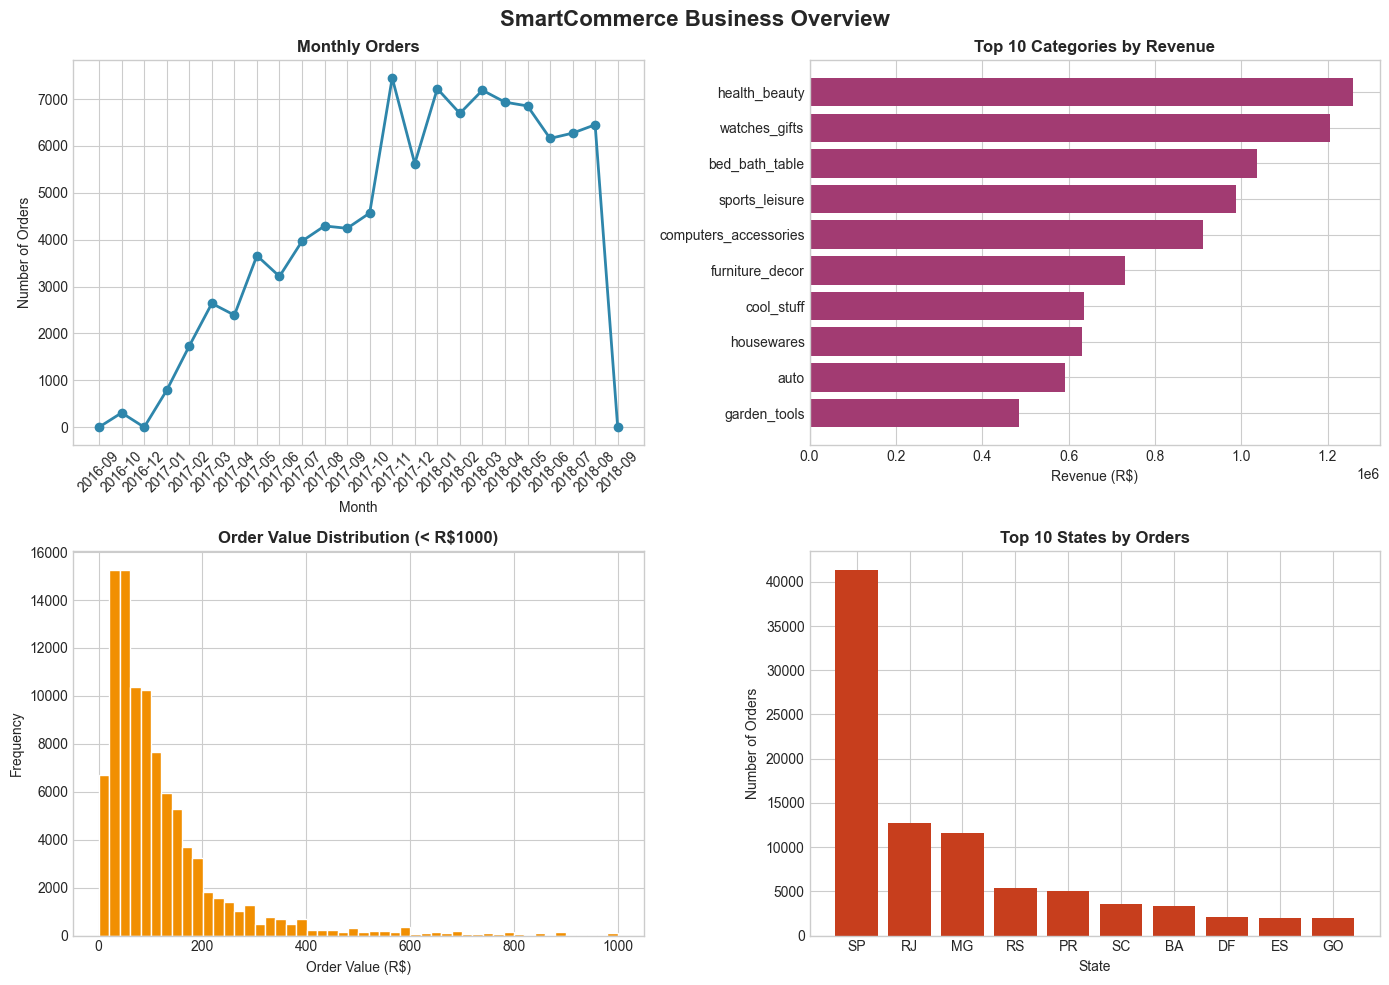

In [27]:
# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid')
fig_color = '#f8f9fa'

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SmartCommerce Business Overview', fontsize=16, fontweight='bold')

# 1. Orders over time
monthly_orders = df.groupby('year_month')['order_id'].nunique()
axes[0, 0].plot(monthly_orders.index, monthly_orders.values, marker='o', linewidth=2, color='#2E86AB')
axes[0, 0].set_title('Monthly Orders', fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Revenue by category (top 10)
cat_revenue = df.groupby('product_category_name_english')['price'].sum().nlargest(10)
axes[0, 1].barh(cat_revenue.index, cat_revenue.values, color='#A23B72')
axes[0, 1].set_title('Top 10 Categories by Revenue', fontweight='bold')
axes[0, 1].set_xlabel('Revenue (R$)')
axes[0, 1].invert_yaxis()

# 3. Order value distribution
order_values = df.groupby('order_id')['price'].sum()
axes[1, 0].hist(order_values[order_values < 1000], bins=50, color='#F18F01', edgecolor='white')
axes[1, 0].set_title('Order Value Distribution (< R$1000)', fontweight='bold')
axes[1, 0].set_xlabel('Order Value (R$)')
axes[1, 0].set_ylabel('Frequency')

# 4. Orders by state (top 10)
state_orders = df.groupby('customer_state')['order_id'].nunique().nlargest(10)
axes[1, 1].bar(state_orders.index, state_orders.values, color='#C73E1D')
axes[1, 1].set_title('Top 10 States by Orders', fontweight='bold')
axes[1, 1].set_xlabel('State')
axes[1, 1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

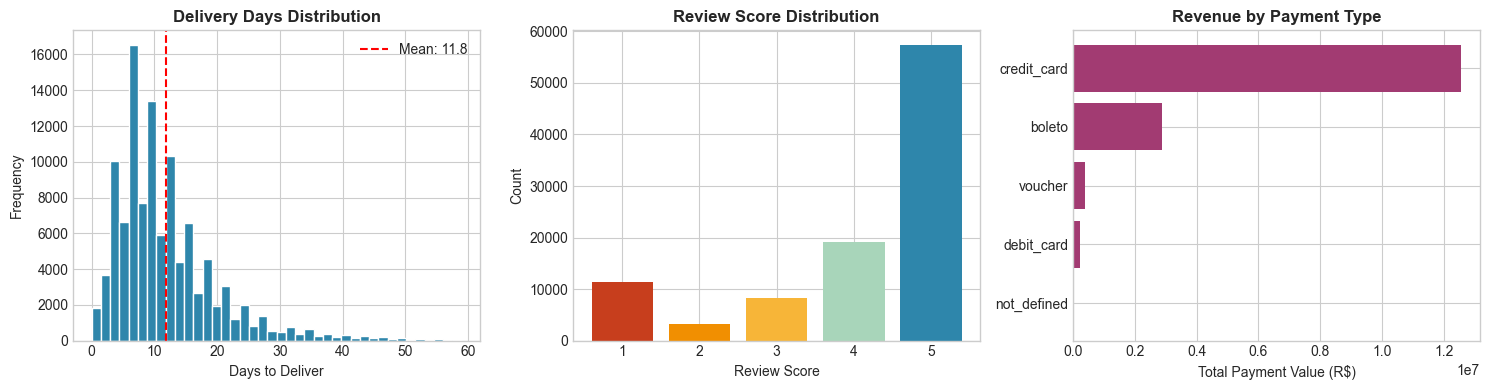

In [28]:
# Delivery and Review Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Delivery days distribution
delivered_data = df[df['delivery_days'].notna() & (df['delivery_days'] < 60)]
axes[0].hist(delivered_data['delivery_days'], bins=40, color='#2E86AB', edgecolor='white')
axes[0].axvline(delivered_data['delivery_days'].mean(), color='red', linestyle='--', label=f"Mean: {delivered_data['delivery_days'].mean():.1f}")
axes[0].set_title('Delivery Days Distribution', fontweight='bold')
axes[0].set_xlabel('Days to Deliver')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Review score distribution
score_counts = olist['reviews']['review_score'].value_counts().sort_index()
colors = ['#C73E1D', '#F18F01', '#F7B538', '#A8D5BA', '#2E86AB']
axes[1].bar(score_counts.index, score_counts.values, color=colors)
axes[1].set_title('Review Score Distribution', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Count')

# 3. Payment type distribution
payment_dist = olist['payments'].groupby('payment_type')['payment_value'].sum().sort_values(ascending=True)
axes[2].barh(payment_dist.index, payment_dist.values, color='#A23B72')
axes[2].set_title('Revenue by Payment Type', fontweight='bold')
axes[2].set_xlabel('Total Payment Value (R$)')

plt.tight_layout()
plt.show()

### 5.1 Delivery estimate vs. actual — how much buffer is in the promise?

Olist shows an estimated delivery date at checkout. Comparing it to reality: the **promised window (median ≈ 23 days) is far longer than the actual delivery time (median ≈ 10 days)**, so ~92% of orders arrive on or before the estimate with ~11 days to spare. That padding is why the on-time rate looks so healthy — and why a "late vs. a *tight* promise" target would be much harder than the raw `is_on_time` flag. The buffer also isn't uniform: remote northern states get a bigger cushion than São Paulo.

delivered orders             : 95,978
median promised window       : 23 days
median actual delivery       : 10 days
median buffer (est - actual) : 11 days early
arrived on/before estimate   : 92.1%


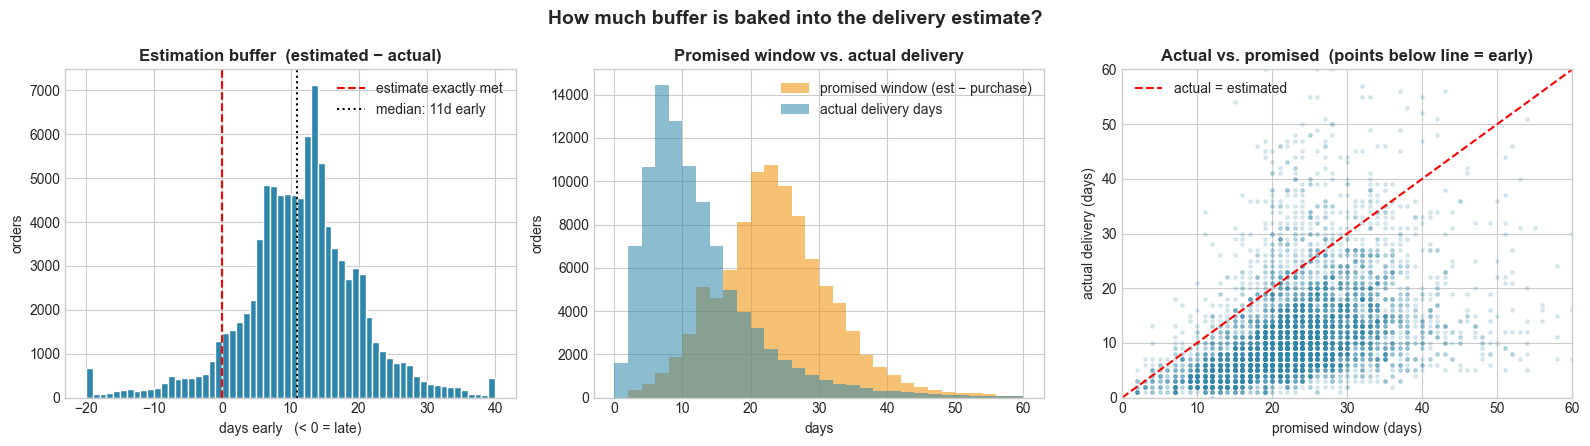

In [29]:
# --- Delivery estimate vs. actual: how much buffer is baked into the promise? ---
d = df.drop_duplicates('order_id').copy()
d = d[d['order_status'] == 'delivered']
d['estimated_days'] = (d['order_estimated_delivery_date'] - d['order_purchase_timestamp']).dt.days   # promised window
d['buffer_days']    = (d['order_estimated_delivery_date'] - d['order_delivered_customer_date']).dt.days  # +ve = arrived early
d = d[d['delivery_days'].between(0, 60) & d['estimated_days'].between(0, 60)]

print(f"delivered orders             : {len(d):,}")
print(f"median promised window       : {d['estimated_days'].median():.0f} days")
print(f"median actual delivery       : {d['delivery_days'].median():.0f} days")
print(f"median buffer (est - actual) : {d['buffer_days'].median():.0f} days early")
print(f"arrived on/before estimate   : {(d['buffer_days'] >= 0).mean():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('How much buffer is baked into the delivery estimate?', fontsize=14, fontweight='bold')

# 1. buffer distribution
axes[0].hist(d['buffer_days'].clip(-20, 40), bins=60, color='#2E86AB', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='estimate exactly met')
axes[0].axvline(d['buffer_days'].median(), color='black', linestyle=':',
                label=f"median: {d['buffer_days'].median():.0f}d early")
axes[0].set_title('Estimation buffer  (estimated − actual)', fontweight='bold')
axes[0].set_xlabel('days early   (< 0 = late)')
axes[0].set_ylabel('orders')
axes[0].legend()

# 2. promised window vs actual delivery, overlaid
bins = np.arange(0, 61, 2)
axes[1].hist(d['estimated_days'], bins=bins, alpha=0.55, color='#F18F01', label='promised window (est − purchase)')
axes[1].hist(d['delivery_days'], bins=bins, alpha=0.55, color='#2E86AB', label='actual delivery days')
axes[1].set_title('Promised window vs. actual delivery', fontweight='bold')
axes[1].set_xlabel('days')
axes[1].set_ylabel('orders')
axes[1].legend()

# 3. actual vs promised scatter with y = x
samp = d.sample(min(6000, len(d)), random_state=0)
axes[2].scatter(samp['estimated_days'], samp['delivery_days'], s=6, alpha=0.15, color='#2E86AB')
axes[2].plot([0, 60], [0, 60], color='red', linestyle='--', label='actual = estimated')
axes[2].set_xlim(0, 60)
axes[2].set_ylim(0, 60)
axes[2].set_title('Actual vs. promised  (points below line = early)', fontweight='bold')
axes[2].set_xlabel('promised window (days)')
axes[2].set_ylabel('actual delivery (days)')
axes[2].legend()

plt.tight_layout()
plt.show()

                median_promised  median_actual  median_buffer      n
customer_state                                                      
AL                        31.00          22.00           9.00    390
MA                        30.00          19.00           9.00    703
SP                        18.00           7.00          10.00  40413
BA                        28.00          16.00          11.00   3219
ES                        25.00          13.00          11.00   1981
MS                        25.00          13.00          11.00    700
SE                        29.00          17.00          12.00    330
SC                        25.00          12.00          12.00   3534
RJ                        24.00          11.00          12.00  12230
TO                        28.00          15.00          12.00    272
GO                        26.00          13.00          12.00   1949
DF                        24.00          11.00          12.00   2077
CE                        31.00   

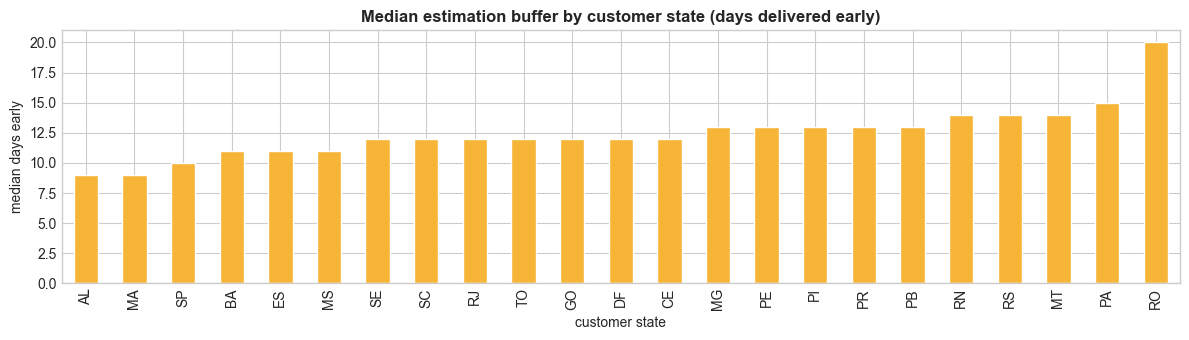

In [30]:
# --- Is the buffer uniform, or padded more for far / remote states? ---
by_state = (d.groupby('customer_state')
              .agg(median_promised=('estimated_days', 'median'),
                   median_actual=('delivery_days', 'median'),
                   median_buffer=('buffer_days', 'median'),
                   n=('order_id', 'size'))
              .query('n >= 200').sort_values('median_buffer'))
print(by_state.to_string())

fig, ax = plt.subplots(figsize=(12, 3.5))
by_state['median_buffer'].plot(kind='bar', ax=ax, color='#F7B538', edgecolor='white')
ax.set_title('Median estimation buffer by customer state (days delivered early)', fontweight='bold')
ax.set_xlabel('customer state')
ax.set_ylabel('median days early')
plt.tight_layout()
plt.show()

---

## 6. Save Prepared Dataset

Save the consolidated dataset for use in future labs.


In [ ]:
# Save consolidated dataset for future labs
# output_path = 'smartcommerce_consolidated.csv'   # written next to this notebook; set your own path
# df.to_csv(output_path, index=False)
# print(f"✅ Saved consolidated dataset to: {output_path}")
# print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
# print(f"   Size: {os.path.getsize(output_path) / 1e6:.2f} MB")

✅ Saved consolidated dataset to: smartcommerce_consolidated.csv
   Shape: 112,650 rows × 25 columns
   Size: 35.62 MB


---

## ✅ Lab Summary

### What you finished!

1. **Data Loading**: Loaded 9 interconnected Olist tables
2. **Schema Understanding**: Identified key columns and relationships
3. **Table Merging**: Built a consolidated analysis dataset using `merge()`
4. **KPI Computation**: Calculated core e-commerce metrics:
   - Revenue & AOV
   - Repeat Rate
   - Delivery Performance
   - Customer Satisfaction


---

## 📝 Exercise (Optional)

1. Calculate the **month-over-month growth rate** for orders
2. Find the **top 5 sellers by revenue**
3. Identify which **product category has the worst delivery performance**


Calculate the month-over-month growth rate for orders

In [32]:
monthly_orders_growth = monthly_orders.pct_change() * 100
print("MONTH-OVER-MONTH ORDER GROWTH RATE (%)")
print("=" * 60)
print(monthly_orders_growth.round(2))
print("=" * 60)

MONTH-OVER-MONTH ORDER GROWTH RATE (%)
year_month
2016-09        NaN
2016-10   10166.67
2016-12     -99.68
2017-01   78800.00
2017-02     119.65
2017-03      52.39
2017-04      -9.47
2017-05      53.07
2017-06     -12.10
2017-07      23.38
2017-08       8.16
2017-09      -1.16
2017-10       7.66
2017-11      63.11
2017-12     -24.52
2018-01      28.38
2018-02      -7.29
2018-03       7.38
2018-04      -3.53
2018-05      -1.17
2018-06     -10.11
2018-07       1.83
2018-08       2.85
2018-09     -99.98
Name: order_id, dtype: float64


Find the top 5 sellers by revenue

In [33]:
seller_revenue = df.groupby('seller_id')['item_revenue'].sum().nlargest(5)

print("TOP 5 SELLERS BY REVENUE")
print("=" * 60)
print(seller_revenue.round(2))
print("=" * 60)

TOP 5 SELLERS BY REVENUE
seller_id
4869f7a5dfa277a7dca6462dcf3b52b2   249640.70
7c67e1448b00f6e969d365cea6b010ab   239536.44
53243585a1d6dc2643021fd1853d8905   235856.68
4a3ca9315b744ce9f8e9374361493884   235539.96
fa1c13f2614d7b5c4749cbc52fecda94   204084.73
Name: item_revenue, dtype: float64


Identify which product category has the worst delivery performance

In [34]:
# Filter for delivered orders to calculate delivery performance
delivered_products = df[df['order_status'] == 'delivered'].copy()

# Calculate on-time delivery rate per product category
category_delivery_performance = delivered_products.groupby('product_category_name_english')['is_on_time'].mean().sort_values()

# Identify the category with the worst (lowest) on-time delivery performance
worst_delivery_category = category_delivery_performance.iloc[0]

print("PRODUCT CATEGORY WITH WORST DELIVERY PERFORMANCE")
print("=" * 60)
print(f"Category: {category_delivery_performance.index[0]} (On-Time Rate: {worst_delivery_category:.1%})")
print("=" * 60)

# Display the full list of category delivery performance for context
print("\nTOP 10 WORST DELIVERY PERFORMING CATEGORIES:")
print("-" * 40)
print(category_delivery_performance.head(10).apply(lambda x: f'{x:.1%}') )

PRODUCT CATEGORY WITH WORST DELIVERY PERFORMANCE
Category: home_comfort_2 (On-Time Rate: 83.3%)

TOP 10 WORST DELIVERY PERFORMING CATEGORIES:
----------------------------------------
product_category_name_english
home_comfort_2                       83.3%
furniture_mattress_and_upholstery    86.5%
audio                                87.3%
fashion_underwear_beach              87.4%
christmas_supplies                   88.0%
books_technical                      89.0%
home_confort                         89.7%
construction_tools_lights            90.0%
food                                 90.2%
electronics                          90.3%
Name: is_on_time, dtype: object
